### Imports

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_motor = pd.read_csv('exports/stream_20240302_035750 (mo12 12m 10r).csv')
df_motor.head()

,Time,Motor1 Pos,Opten1 PosX,Opten1 PosY,Motor2 Pos,Opten2 PosX,Opten2 PosY
0,0.032,0.0,0.0,0.004,-0.019,-0.002,0.0
1,0.144,0.0,0.0,0.002,-0.019,-0.002,0.0
2,0.256,0.0,0.0,0.004,-0.019,-0.002,0.0
3,0.368,0.0,0.0,0.004,-0.019,-0.002,0.0
4,0.480,0.0,0.0,0.004,-0.019,-0.002,0.0


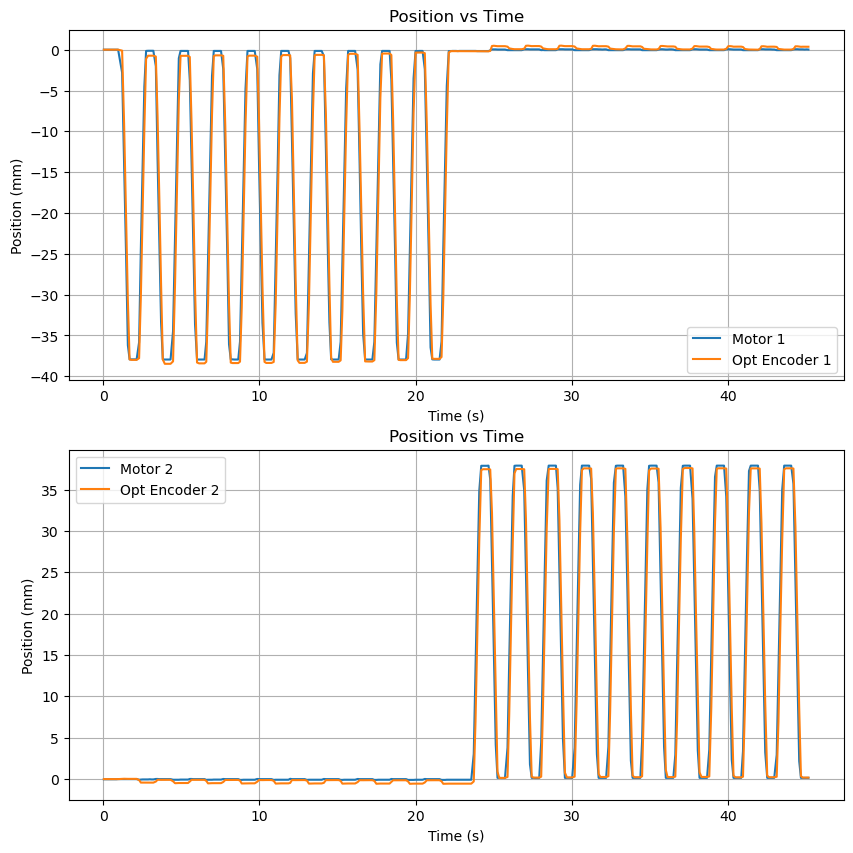

In [3]:
time_motor = df_motor['Time'].values
x_motor1 = df_motor['Motor1 Pos'].values
x_opten1 = df_motor['Opten1 PosX'].values
y_opten1 = df_motor['Opten1 PosY'].values
x_motor2 = df_motor['Motor2 Pos'].values
x_opten2 = -df_motor['Opten2 PosX'].values
y_opten2 = df_motor['Opten2 PosY'].values

fig, ax = plt.subplots(2, 1, figsize=(10, 10))
ax[0].plot(time_motor, x_motor1, label='Motor 1')
ax[0].plot(time_motor, x_opten1, label='Opt Encoder 1')
ax[1].plot(time_motor, x_motor2, label='Motor 2')
ax[1].plot(time_motor, x_opten2, label='Opt Encoder 2')
ax[0].set_title('Position vs Time')
ax[1].set_title('Position vs Time')
ax[0].set_xlabel('Time (s)')
ax[1].set_xlabel('Time (s)')
ax[0].set_ylabel('Position (mm)')
ax[1].set_ylabel('Position (mm)')
ax[0].legend()
ax[1].legend()
ax[0].grid()
ax[1].grid()
plt.show()

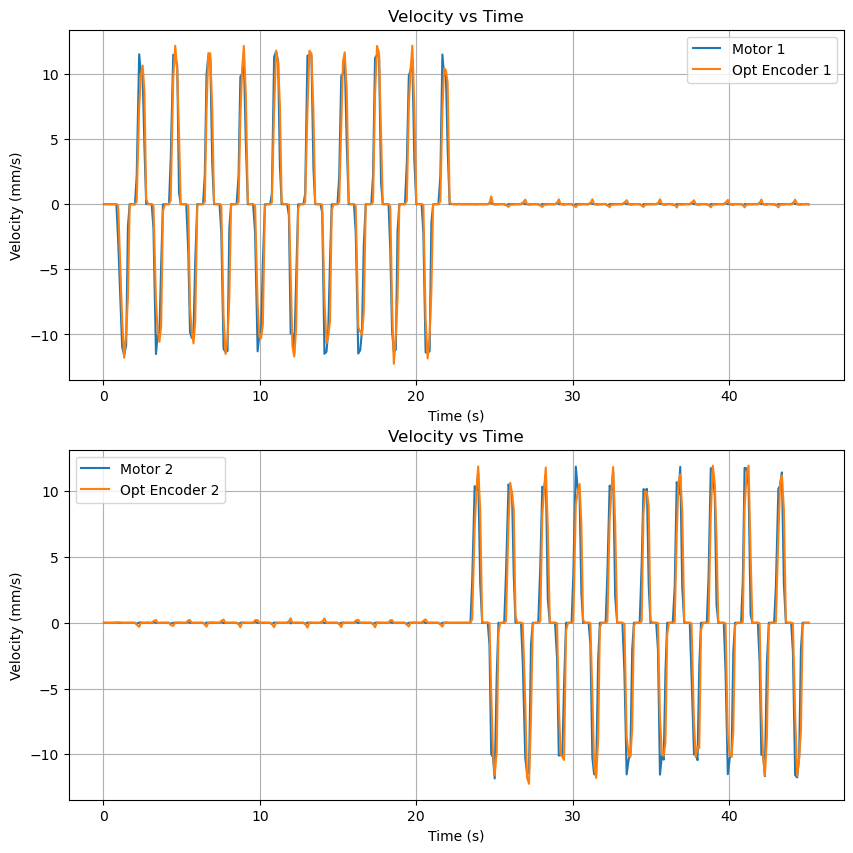

In [5]:
x_motor1_diff = np.diff(x_motor1)
x_opten1_diff = np.diff(x_opten1)
y_opten1_diff = np.diff(y_opten1)
x_motor2_diff = np.diff(x_motor2)
x_opten2_diff = np.diff(x_opten2)
y_opten2_diff = np.diff(y_opten2)

fig, ax = plt.subplots(2, 1, figsize=(10, 10))
ax[0].plot(time_motor[:-1], x_motor1_diff, label='Motor 1')
ax[0].plot(time_motor[:-1], x_opten1_diff, label='Opt Encoder 1')
ax[1].plot(time_motor[:-1], x_motor2_diff, label='Motor 2')
ax[1].plot(time_motor[:-1], x_opten2_diff, label='Opt Encoder 2')
ax[0].set_title('Velocity vs Time')
ax[1].set_title('Velocity vs Time')
ax[0].set_xlabel('Time (s)')
ax[1].set_xlabel('Time (s)')
ax[0].set_ylabel('Velocity (mm/s)')
ax[1].set_ylabel('Velocity (mm/s)')
ax[0].legend()
ax[1].legend()
ax[0].grid()
ax[1].grid()
plt.show()

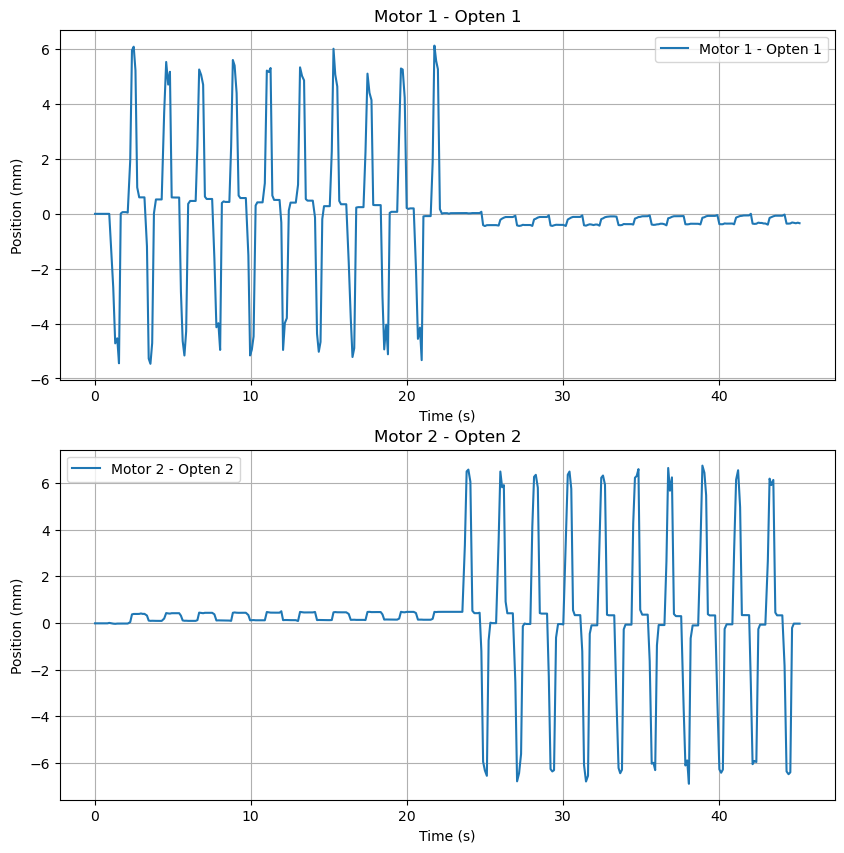

In [4]:
# plot differences
fig, ax = plt.subplots(2, 1, figsize=(10, 10))
ax[0].plot(time_motor, x_motor1 - x_opten1, label='Motor 1 - Opten 1')
ax[1].plot(time_motor, x_motor2 - x_opten2, label='Motor 2 - Opten 2')
ax[0].set_title('Motor 1 - Opten 1')
ax[1].set_title('Motor 2 - Opten 2')
ax[0].set_xlabel('Time (s)')
ax[1].set_xlabel('Time (s)')
ax[0].set_ylabel('Position (mm)')
ax[1].set_ylabel('Position (mm)')
ax[0].legend()
ax[1].legend()
ax[0].grid()
ax[1].grid()
plt.show()